# Visualize Processed TerraSAR-X Dataset

This notebook is a messy file where I experiment with/visualize the preprocessed TerraSAR-X datasets created by `scripts/TSX_dataset_creation.py`.

In [ ]:
import sys
import random
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add parent directory to path to import from src
sys.path.append(str(Path().resolve().parent))

# Import normalize_sar function from utils
from src.utils.sar_utils import (
    convert_from_db,
    convert_to_db,
    denormalize_minmax_log10,
    denormalize_minmax_log_natural,
    normalize_minmax_log10,
    normalize_minmax_log_natural,
    m,
    M,
)

seed = 1
random.seed(seed)
dataset_global_dir = Path("../data/processed_hdf5")

In [ ]:
def visualize_random_patches(dataset, num_patches=3):
    """
    Visualize random patches from the dataset.

    Args:
        dataset: Dataset containing patches
        num_patches: Number of random patches to visualize
        seed: Random seed for reproducibility
    """
    n_samples = dataset.shape[0]
    indices = random.sample(range(n_samples), num_patches)

    fig, axes = plt.subplots(num_patches, 3, figsize=(15, 5 * num_patches))
    for i, idx in enumerate(indices):
        patch = dataset[idx]
        real_part = patch[:, :, 0]
        imag_part = patch[:, :, 1]
        intensity = real_part + imag_part

        # Plot real part
        im0 = axes[i, 0].imshow(real_part, cmap="gray")
        axes[i, 0].set_title(f"Real Part - Patch {idx}")
        axes[i, 0].axis("off")
        fig.colorbar(im0, ax=axes[i, 0], shrink=0.7)

        # Plot imaginary part
        im1 = axes[i, 1].imshow(imag_part, cmap="gray")
        axes[i, 1].set_title(f"Imaginary Part - Patch {idx}")
        axes[i, 1].axis("off")
        fig.colorbar(im1, ax=axes[i, 1], shrink=0.7)

        # Plot intensity
        im2 = axes[i, 2].imshow(intensity, cmap="gray")
        axes[i, 2].set_title(f"Sum - Patch {idx}")
        axes[i, 2].axis("off")
        fig.colorbar(im2, ax=axes[i, 2], shrink=0.7)

    plt.tight_layout()
    return fig

## Visualize a few samples of one specific dataset

train_patches shape: (27836, 256, 256, 2)


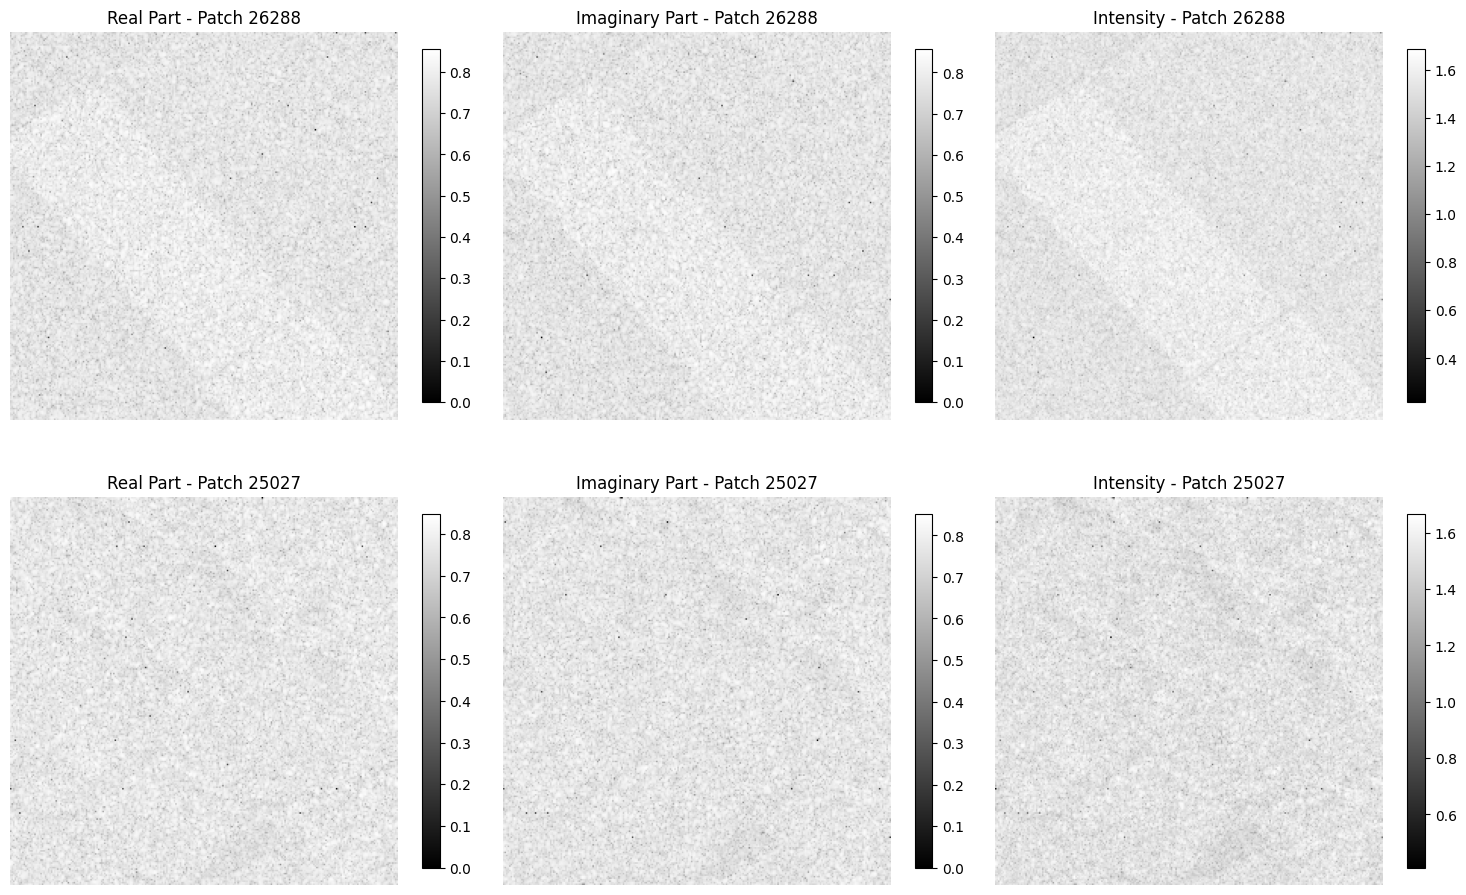

In [4]:
train_file = dataset_global_dir / "randomsplit5_nopres_norm0nat" / "train.h5"
with h5py.File(train_file, "r") as f:
    train_patches = f["patches"]
    print(f"train_patches shape: {train_patches.shape}")
    visualize_random_patches(train_patches, num_patches=2)

## Load HDF5 Datasets

Load the train, validation, and test datasets created by the TSX_dataset_creation.py script.

In [ ]:
seed = 1

# Paths to the HDF5 datasets
data_dir = Path("../data/processed_hdf5/randomsplit5_nopres_norm0nat")
train_path = data_dir / "train.h5"
val_path = data_dir / "val.h5"
test_path = data_dir / "test.h5"

# Check if files exist
for path in [train_path, val_path, test_path]:
    if not path.exists():
        print(f"Warning: {path} does not exist!")

# Load datasets
train_data = h5py.File(str(train_path), "r")
val_data = h5py.File(str(val_path), "r")
test_data = h5py.File(str(test_path), "r")

print(f"Train dataset shape: {train_data['patches'].shape}")
print(f"Validation dataset shape: {val_data['patches'].shape}")
print(f"Test dataset shape: {test_data['patches'].shape}")

## Print Dataset Attributes

Display the metadata attributes stored in the HDF5 files.

In [ ]:
# Print dataset attributes
print("Test dataset attributes:")
for key, value in test_data.attrs.items():
    print(f"  {key}: {value}")

## Calculate statistics

In [ ]:
# compute the statistics of the training set
def compute_statistics(data):
    """
    Compute the mean and standard deviation of the dataset.
    """
    metrics = {}
    metrics["mean"] = np.mean(data)
    metrics["std"] = np.std(data)
    metrics["min"] = np.min(data)
    metrics["max"] = np.max(data)
    metrics["p1"] = np.percentile(data, 1)
    metrics["p5"] = np.percentile(data, 5)
    metrics["p10"] = np.percentile(data, 10)
    metrics["p90"] = np.percentile(data, 90)
    metrics["p95"] = np.percentile(data, 95)
    metrics["p99"] = np.percentile(data, 99)
    return metrics

### RAW dataset

In [ ]:
test_patches = test_data["patches"][:]

print("\nTesting set statistics Re:")
print(compute_statistics(test_patches[:, :, :, 0]))

print("\nTesting set statistics log10 Re:")
print(compute_statistics(convert_to_db(test_patches[:, :, :, 0])))

In [ ]:
test_patches = test_data["patches"][:]


def norm_minmax(x, min, max):
    return (x - min) / (max - min)


# ------ Base 10: in DB ------
re_log_10 = convert_to_db(test_patches[:, :, :, 0])
stats_re_log_10 = compute_statistics(re_log_10)
print(f"\nTesting set statistics log10 Re: {stats_re_log_10}")

re_log_10_minmax = norm_minmax(
    re_log_10, stats_re_log_10["min"], stats_re_log_10["max"]
)
stats_re_log_10_minmax = compute_statistics(re_log_10_minmax)
print(f"\nTesting set statistics log10 Re minmax: {stats_re_log_10_minmax}")

re_log_10_p1p99 = norm_minmax(re_log_10, stats_re_log_10["p1"], stats_re_log_10["p99"])
stats_re_log_10_p1p99 = compute_statistics(re_log_10_p1p99)
print(f"\nTesting set statistics log10 Re p1p99: {stats_re_log_10_p1p99}")

re_log_10_p5p95 = norm_minmax(re_log_10, stats_re_log_10["p5"], stats_re_log_10["p95"])
stats_re_log_10_p5p95 = compute_statistics(re_log_10_p5p95)
print(f"\nTesting set statistics log10 Re p5p95: {stats_re_log_10_p5p95}")

# ------ Natural Log ------
re_log_nat = np.log(test_patches[:, :, :, 0] + np.spacing(1))
stats_re_log_nat = compute_statistics(re_log_nat)
print(f"\nTesting set statistics log nat Re: {stats_re_log_nat}")

re_log_nat_minmax = norm_minmax(
    re_log_nat, stats_re_log_nat["min"], stats_re_log_nat["max"]
)
stats_re_log_nat_minmax = compute_statistics(re_log_nat_minmax)
print(f"\nTesting set statistics log nat Re minmax: {stats_re_log_nat_minmax}")

re_log_nat_p1p99 = norm_minmax(
    re_log_nat, stats_re_log_nat["p1"], stats_re_log_nat["p99"]
)
stats_re_log_nat_p1p99 = compute_statistics(re_log_nat_p1p99)
print(f"\nTesting set statistics log nat Re p1p99: {stats_re_log_nat_p1p99}")

re_log_nat_p5p95 = norm_minmax(
    re_log_nat, stats_re_log_nat["p5"], stats_re_log_nat["p95"]
)
stats_re_log_nat_p5p95 = compute_statistics(re_log_nat_p5p95)
print(f"\nTesting set statistics log nat Re p5p95: {stats_re_log_nat_p5p95}")

### Normalized patches
As they are processed by the network

In [ ]:
# Create a new list of patches with the same shape as the original
# but with the real and imaginary components normalized
test_norm_nat_patches = np.zeros_like(test_patches)
test_norm_10_patches = np.zeros_like(test_patches)
for i in range(test_patches.shape[0]):
    test_norm_nat_patches[i, :, :, 0] = normalize_minmax_log_natural(
        test_patches[i, :, :, 0]
    )
    test_norm_10_patches[i, :, :, 0] = normalize_minmax_log10(test_patches[i, :, :, 0])

print(
    f"\nNormalized(Re) log natural: {compute_statistics(test_norm_nat_patches[:, :, :, 0])}"
)
print(
    f"\nNormalized(Re) log 10: {compute_statistics(test_norm_10_patches[:, :, :, 0])}"
)


### Trying other normalization

In [ ]:
stop

## Create Visualization Function

Define a function to visualize random samples from a dataset.

In [ ]:
def visualize_random_patches(dataset, num_patches=3, seed=42):
    """
    Visualize random patches from the dataset.

    Args:
        dataset: HDF5 dataset containing patches
        num_patches: Number of random patches to visualize
        seed: Random seed for reproducibility
    """
    # Set seed for reproducibility
    random.seed(seed)

    # Get dataset size
    n_samples = dataset["patches"].shape[0]

    # Select random indices
    indices = random.sample(range(n_samples), num_patches)

    # Create figure
    fig, axes = plt.subplots(num_patches, 3, figsize=(15, 5 * num_patches))

    # For each random patch
    for i, idx in enumerate(indices):
        # Get the patch
        patch = dataset["patches"][idx]

        # Extract real and imaginary components (already squared from processing)
        real_part = patch[:, :, 0]
        imag_part = patch[:, :, 1]

        # Calculate intensity (sum of squared real and imaginary parts)

        # Apply normalization for visualization
        real_norm = normalize_sar(real_part)
        imag_norm = normalize_sar(imag_part)
        intensity_norm = real_norm + imag_norm

        # Plot real part
        im0 = axes[i, 0].imshow(real_norm, cmap="gray")
        axes[i, 0].set_title(f"Real Part (Squared) - Patch {idx}")
        axes[i, 0].axis("off")
        fig.colorbar(im0, ax=axes[i, 0], shrink=0.7)

        # Plot imaginary part
        im1 = axes[i, 1].imshow(imag_norm, cmap="gray")
        axes[i, 1].set_title(f"Imaginary Part (Squared) - Patch {idx}")
        axes[i, 1].axis("off")
        fig.colorbar(im1, ax=axes[i, 1], shrink=0.7)

        # Plot intensity
        im2 = axes[i, 2].imshow(intensity_norm, cmap="gray")
        axes[i, 2].set_title(f"Intensity - Patch {idx}")
        axes[i, 2].axis("off")
        fig.colorbar(im2, ax=axes[i, 2], shrink=0.7)

    plt.tight_layout()
    return fig

## Visualize Training Dataset Samples

Display 3 random samples from the training dataset.

In [ ]:
# Set different seeds for each dataset to get different samples
fig_train = visualize_random_patches(train_data, num_patches=3, seed=seed)
plt.suptitle("Training Dataset Samples", fontsize=16)
plt.show()

## Visualize Validation Dataset Samples

Display 3 random samples from the validation dataset.

In [ ]:
fig_val = visualize_random_patches(val_data, num_patches=3, seed=seed)
plt.suptitle("Validation Dataset Samples", fontsize=16)
plt.show()

## Visualize Test Dataset Samples

Display 3 random samples from the test dataset.

In [ ]:
fig_test = visualize_random_patches(test_data, num_patches=3, seed=seed)
plt.suptitle("Test Dataset Samples", fontsize=16)
plt.show()

## Observations

The visualizations above show random patches from the processed TerraSAR-X dataset. Each row represents a different patch, and the columns show:

1. **Left Column**: Real part (squared) - Shows the squared real component of the SAR data
2. **Middle Column**: Imaginary part (squared) - Shows the squared imaginary component of the SAR data
3. **Right Column**: Intensity - Sum of squared real and imaginary parts

All images are normalized using the `normalize_sar()` function which applies a log transform and normalizes using predetermined 5th and 95th percentile values:
- 5th percentile: 28.17565727233887 dB
- 95th percentile: 50.32925033569336 dB

The dataset contains processed SAR data where:
- The real and imaginary parts have been symmetrized to ensure proper zero-Doppler centering
- The values are already squared in both real and imaginary channels
- Point-like scatterers have been preserved during processing

In [ ]:
# Close the HDF5 files
train_data.close()
val_data.close()
test_data.close()

print("HDF5 files closed successfully.")